Epoch 50, Loss: 0.0189
Epoch 100, Loss: 0.0020
Epoch 150, Loss: 0.0009
Epoch 200, Loss: 0.0005


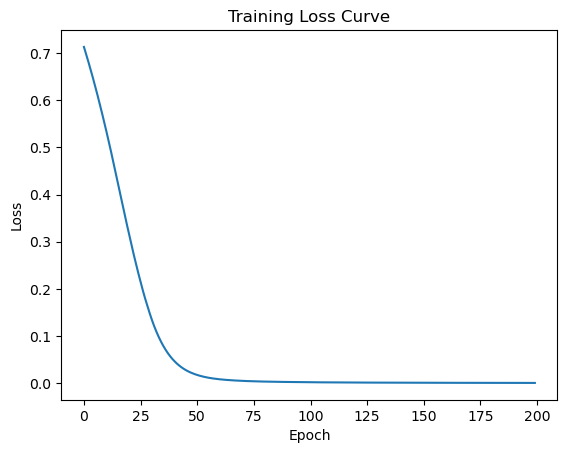

Training accuracy: 1.00


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import matplotlib.pyplot as plt

# 数据
texts = [
    "可能是今年最好的华语电影",
    "太好了,好得说不出话",
    "关于爱与善良,今年最动人的国产电影",
    "女性互助的情谊很动人",
    "很难不为那个时代的女性落泪",
    "电影情节让我感到不适",
    "看似歌颂情谊实则是对落后伦理的美化",
    "我很讨厌这部电影的底层逻辑",
    "试听编排很差",
    "技巧与审美不足"
]
labels = [1,1,1,1,1, 0,0,0,0,0]

# 文本转向量
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts).toarray().astype(np.float32)
y = np.array(labels, dtype=np.int64)

X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y)

# 定义模型
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=16, output_dim=2):
        super(MLPClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = MLPClassifier(input_dim=X.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 训练
losses = []
epochs = 200
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch+1) % 50 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

# 绘制损失曲线
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.savefig('loss_curve.png')
plt.show()

# 准确率
_, predicted = torch.max(model(X_tensor), 1)
accuracy = (predicted == y_tensor).float().mean()
print(f'Training accuracy: {accuracy:.2f}')